<a href="https://colab.research.google.com/github/Gurirath/VIT---EDA---Projects---Classwork--25BAI0153/blob/main/Exp_6_25_8_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Import Libraries and Load Dataset

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Loading the dataset from seaborn
df = sns.load_dataset('iris')
display(df.head())

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### 2. Check Data Types
Reviewing the format of each column.

In [14]:
print("Column Data Types:")
print(df.dtypes)

Column Data Types:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


### 3. Dataset Info
Overview of entries and memory usage.

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


### 4. Statistical Summary
Descriptive statistics for numerical columns.

In [16]:
display(df.describe())

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### 5. Null Value Check
Ensuring there are no missing values.

In [17]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


### 6. Value Mapping
Converting the 'species' object to numerical categories for analysis.

In [18]:
# Mapping species to numbers: setosa=0, versicolor=1, virginica=2
df['species_cat'] = df['species'].astype('category').cat.codes
display(df[['species', 'species_cat']].drop_duplicates())

,species,species_cat
0,setosa,0
50,versicolor,1
100,virginica,2


### 7. Visualization: Histogram
Distribution of Sepal Length.

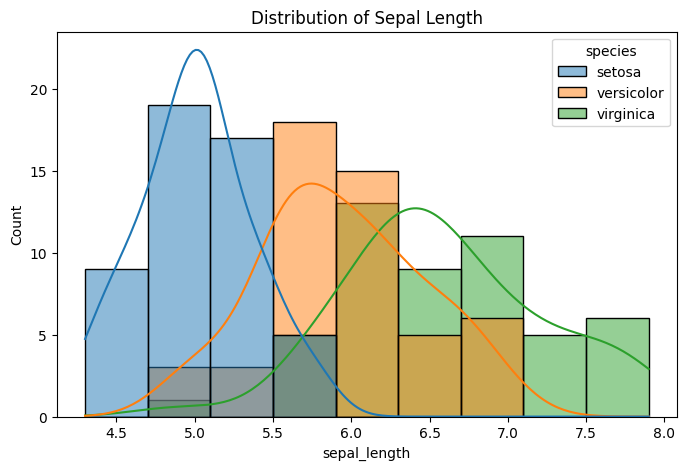

In [19]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='sepal_length', hue='species', kde=True)
plt.title('Distribution of Sepal Length')
plt.show()

### 8. Visualization: Box Plot
Comparing Petal Length across species.

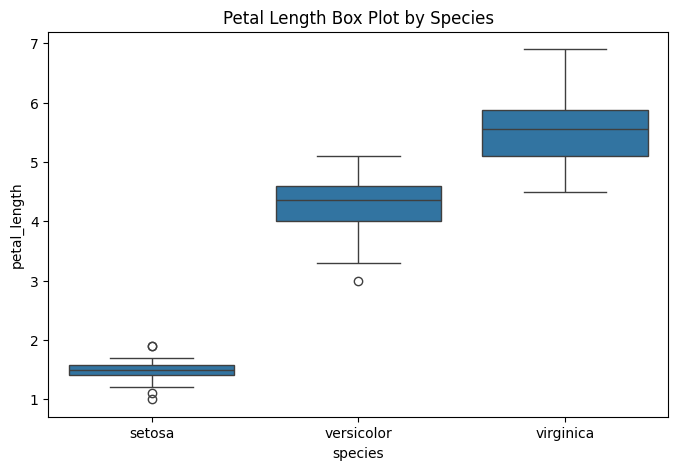

In [20]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='species', y='petal_length', data=df)
plt.title('Petal Length Box Plot by Species')
plt.show()

### 9. Visualization: Scatter Plot
Relationship between Sepal Width and Sepal Length.

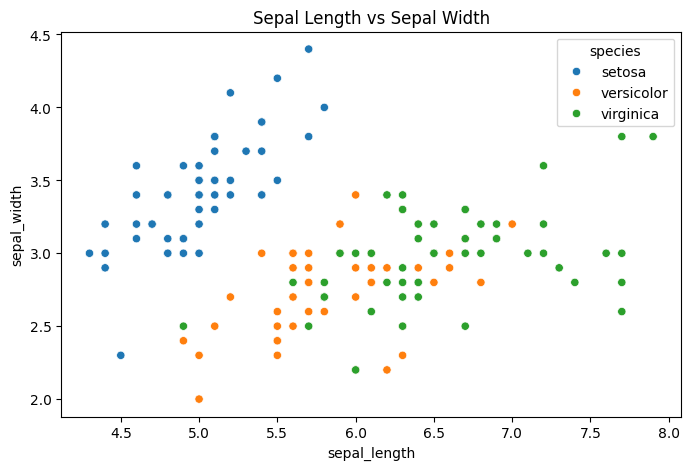

In [21]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='sepal_length', y='sepal_width', hue='species', data=df)
plt.title('Sepal Length vs Sepal Width')
plt.show()

### 10. Visualization: Violin Plot
Distribution density of Petal Width.

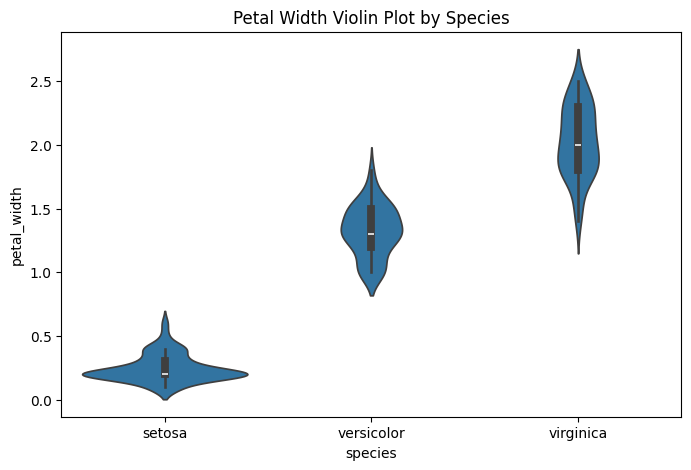

In [22]:
plt.figure(figsize=(8, 5))
sns.violinplot(x='species', y='petal_width', data=df)
plt.title('Petal Width Violin Plot by Species')
plt.show()

### 11. Visualization: Heatmap
Correlation between numerical features.

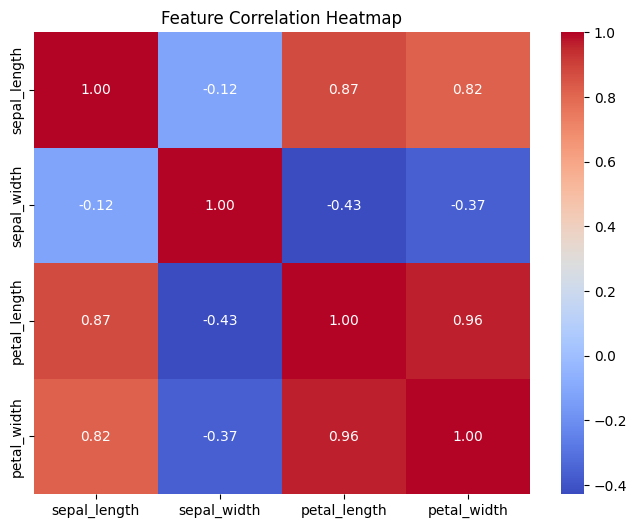

In [23]:
plt.figure(figsize=(8, 6))
corr = df.select_dtypes(include=[np.number]).drop(columns=['species_cat']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

### 12. Data Standardization
Scaling features to have a mean of 0 and a variance of 1.

In [24]:
scaler = StandardScaler()
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
df_scaled = df.copy()
df_scaled[features] = scaler.fit_transform(df[features])

print("Standardized Data Head:")
display(df_scaled.head())

Standardized Data Head:


,sepal_length,sepal_width,petal_length,petal_width,species,species_cat
0,-0.900681,1.019004,-1.340227,-1.315444,setosa,0
1,-1.143017,-0.131979,-1.340227,-1.315444,setosa,0
2,-1.385353,0.328414,-1.397064,-1.315444,setosa,0
3,-1.506521,0.098217,-1.283389,-1.315444,setosa,0
4,-1.021849,1.249201,-1.340227,-1.315444,setosa,0


### 13. Verification of Scaling
Confirming mean is ~0 and standard deviation is ~1.

In [25]:
print("Mean of scaled features:")
print(df_scaled[features].mean().round(2))
print("\nStandard Deviation of scaled features:")
print(df_scaled[features].std().round(2))

Mean of scaled features:
sepal_length   -0.0
sepal_width    -0.0
petal_length   -0.0
petal_width    -0.0
dtype: float64

Standard Deviation of scaled features:
sepal_length    1.0
sepal_width     1.0
petal_length    1.0
petal_width     1.0
dtype: float64
